### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

In [3]:
import warnings
warnings.filterwarnings('ignore')

### Step 2: Read Data

In [4]:
df = pd.read_csv('./data/Zillow.csv')

In [5]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,fireplaceflag,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,target
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,485713.0,1023282.0,2016.0,537569.0,11013.72,NaN,NaN,6.059063e+13,0.025595
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,88000.0,464000.0,2016.0,376000.0,5672.48,NaN,NaN,6.111001e+13,0.055619
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,85289.0,564778.0,2016.0,479489.0,6488.30,NaN,NaN,6.059022e+13,0.005383
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,108918.0,145143.0,2016.0,36225.0,1777.51,NaN,NaN,6.037300e+13,-0.103410
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,73681.0,119407.0,2016.0,45726.0,1533.89,NaN,NaN,6.037124e+13,0.006940


In [6]:
df.shape

(77613, 59)

### Step 3: Data Cleaning

In [7]:
to_remove = list()

In [14]:
for col in df.columns:
    if df[col].nunique() == 1 or df[col].isnull().mean() > 0.6:
        to_remove.append(col)

In [15]:
len(to_remove)

30

In [16]:
df.drop(to_remove, axis=1, inplace=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   bathroomcnt                   77579 non-null  float64
 2   bedroomcnt                    77579 non-null  float64
 3   buildingqualitytypeid         49809 non-null  float64
 4   calculatedbathnbr             76963 non-null  float64
 5   calculatedfinishedsquarefeet  77378 non-null  float64
 6   finishedsquarefeet12          73923 non-null  float64
 7   fips                          77579 non-null  float64
 8   fullbathcnt                   76963 non-null  float64
 9   heatingorsystemtypeid         49571 non-null  float64
 10  latitude                      77579 non-null  float64
 11  longitude                     77579 non-null  float64
 12  lotsizesquarefeet             69321 non-null  float64
 13  p

<Axes: >

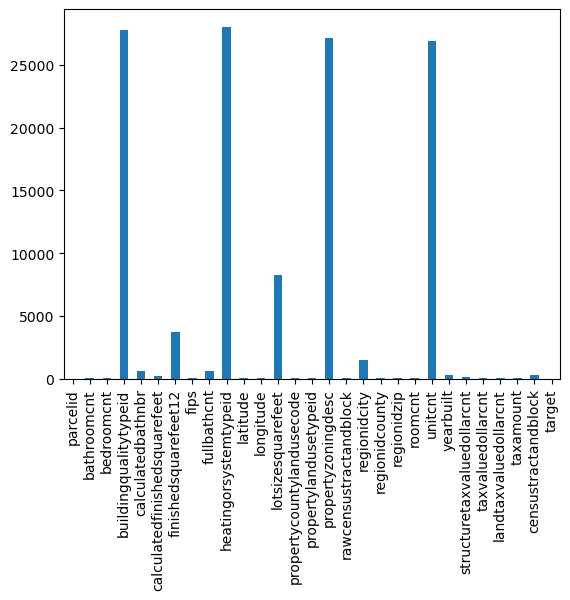

In [20]:
df.isnull().sum().plot.bar()

In [23]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0]) # 使用出现次数最多的值填充
    elif df[col].dtype == np.number:
        df[col] = df[col].fillna(df[col].mean())

In [25]:
df.isnull().sum()

parcelid                        0
bathroomcnt                     0
bedroomcnt                      0
buildingqualitytypeid           0
calculatedbathnbr               0
calculatedfinishedsquarefeet    0
finishedsquarefeet12            0
fips                            0
fullbathcnt                     0
heatingorsystemtypeid           0
latitude                        0
longitude                       0
lotsizesquarefeet               0
propertycountylandusecode       0
propertylandusetypeid           0
propertyzoningdesc              0
rawcensustractandblock          0
regionidcity                    0
regionidcounty                  0
regionidzip                     0
roomcnt                         0
unitcnt                         0
yearbuilt                       0
structuretaxvaluedollarcnt      0
taxvaluedollarcnt               0
landtaxvaluedollarcnt           0
taxamount                       0
censustractandblock             0
target                          0
dtype: int64

### Step 4: Exploratory Data Analysis

In [38]:
ints, objects, floats = list(), list(), list()

In [39]:
for col in df.columns:
    if df[col].dtype == np.float_:
        floats.append(col)
    elif df[col].dtype == np.int64:
        ints.append(col)
    else:
        objects.append(col)

In [40]:
print('number of float:', len(floats), '\nnumber of int:', len(ints), '\nnumber of object:', len(objects))

number of float: 26 
number of int: 1 
number of object: 2


In [42]:
for col in objects:
    print(col, '->', df[col].nunique())
    print(df[col].unique())
    print()

propertycountylandusecode -> 75
['122' '1110' '0101' '010C' '1129' '0100' '38' '34' '1111' '012C' '010V'
 '1' '0103' '010D' '0200' '010E' '0300' '96' '0104' '0400' '01DC' '01HC'
 '1321' '1410' '0108' '1128' '010G' '1720' '010H' '1210' '0102' '010F'
 '010M' '1117' '0201' '0700' '1722' '73' '0109' '0301' '01HE' '135' '0204'
 '0401' '070D' '0113' '0133' '0131' '1432' '040G' '1112' '1222' '1310'
 '1120' '0111' '1116' '1421' '0110' '0105' '012E' '0141' '1333' '0115'
 '040V' '010L' '040B' '012D' '0114' '0203' '030G' '0130' '105' '020G'
 '020M' '020E']

propertyzoningdesc -> 1907
['LAR1' 'LCR110000*' 'LAR3' ... 'HAR4-R2*' 'LCR1VV' 'BFA15000*']



<Axes: ylabel='target'>

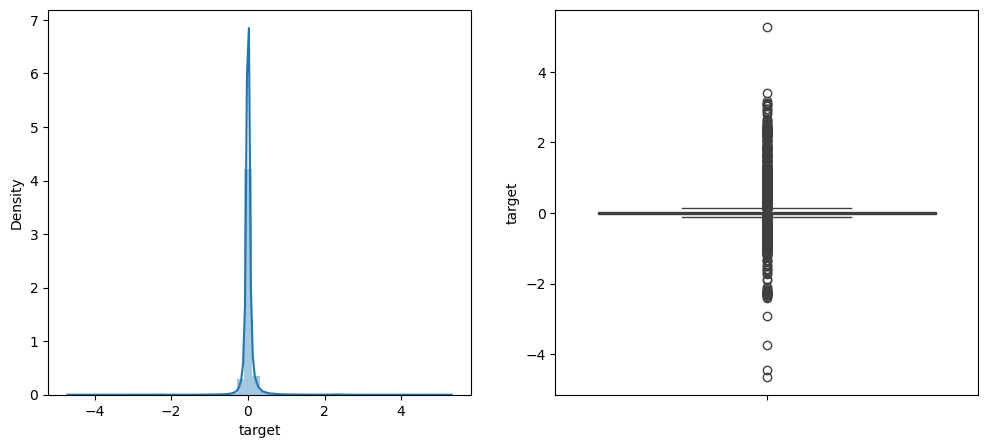

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.distplot(df['target'], ax=ax[0])
sns.boxplot(df['target'], ax=ax[1])

### Step 5: Preparing Data

In [49]:
print('Shape of the dataframe before removal of outliers', df.shape)
df = df[(df['target'] > -1) & (df['target'] < 1)]
print('Shape of the dataframe after removal of outliers ', df.shape)

Shape of the dataframe before removal of outliers (77613, 29)
Shape of the dataframe after removal of outliers  (77261, 29)


<Axes: ylabel='target'>

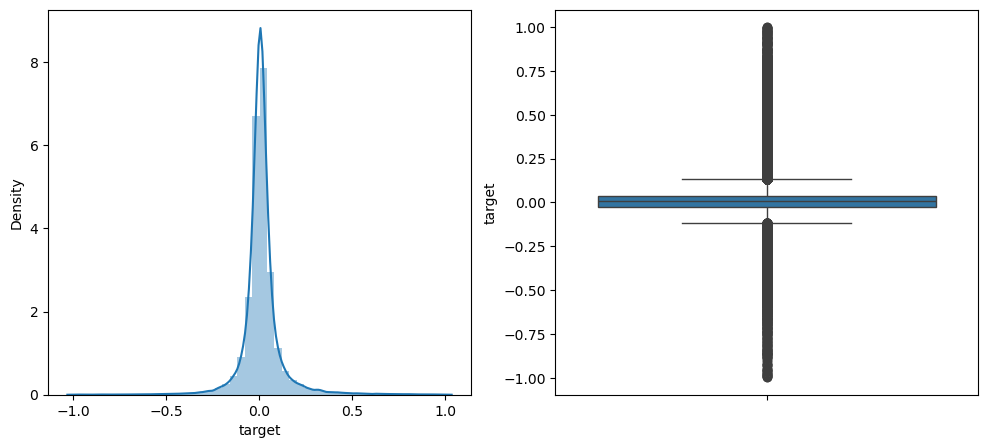

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.distplot(df['target'], ax=ax[0])
sns.boxplot(df['target'], ax=ax[1])

In [51]:
df.head()

,parcelid,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,...,regionidzip,roomcnt,unitcnt,yearbuilt,structuretaxvaluedollarcnt,taxvaluedollarcnt,landtaxvaluedollarcnt,taxamount,censustractandblock,target
0,14297519,3.5,4.0,6.533779,3.5,3100.0,3100.0,6059.0,3.0,3.921749,...,96978.0,0.0,1.110309,1998.0,485713.0,1023282.0,537569.0,11013.72,6.059063e+13,0.025595
1,17052889,1.0,2.0,6.533779,1.0,1465.0,1465.0,6111.0,1.0,3.921749,...,97099.0,5.0,1.110309,1967.0,88000.0,464000.0,376000.0,5672.48,6.111001e+13,0.055619
2,14186244,2.0,3.0,6.533779,2.0,1243.0,1243.0,6059.0,2.0,3.921749,...,97078.0,6.0,1.110309,1962.0,85289.0,564778.0,479489.0,6488.30,6.059022e+13,0.005383
3,12177905,3.0,4.0,8.000000,3.0,2376.0,2376.0,6037.0,3.0,2.000000,...,96330.0,0.0,1.000000,1970.0,108918.0,145143.0,36225.0,1777.51,6.037300e+13,-0.103410
4,10887214,3.0,3.0,8.000000,3.0,1312.0,1312.0,6037.0,3.0,2.000000,...,96451.0,0.0,1.000000,1964.0,73681.0,119407.0,45726.0,1533.89,6.037124e+13,0.006940


In [54]:
for col in objects:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

<Axes: >

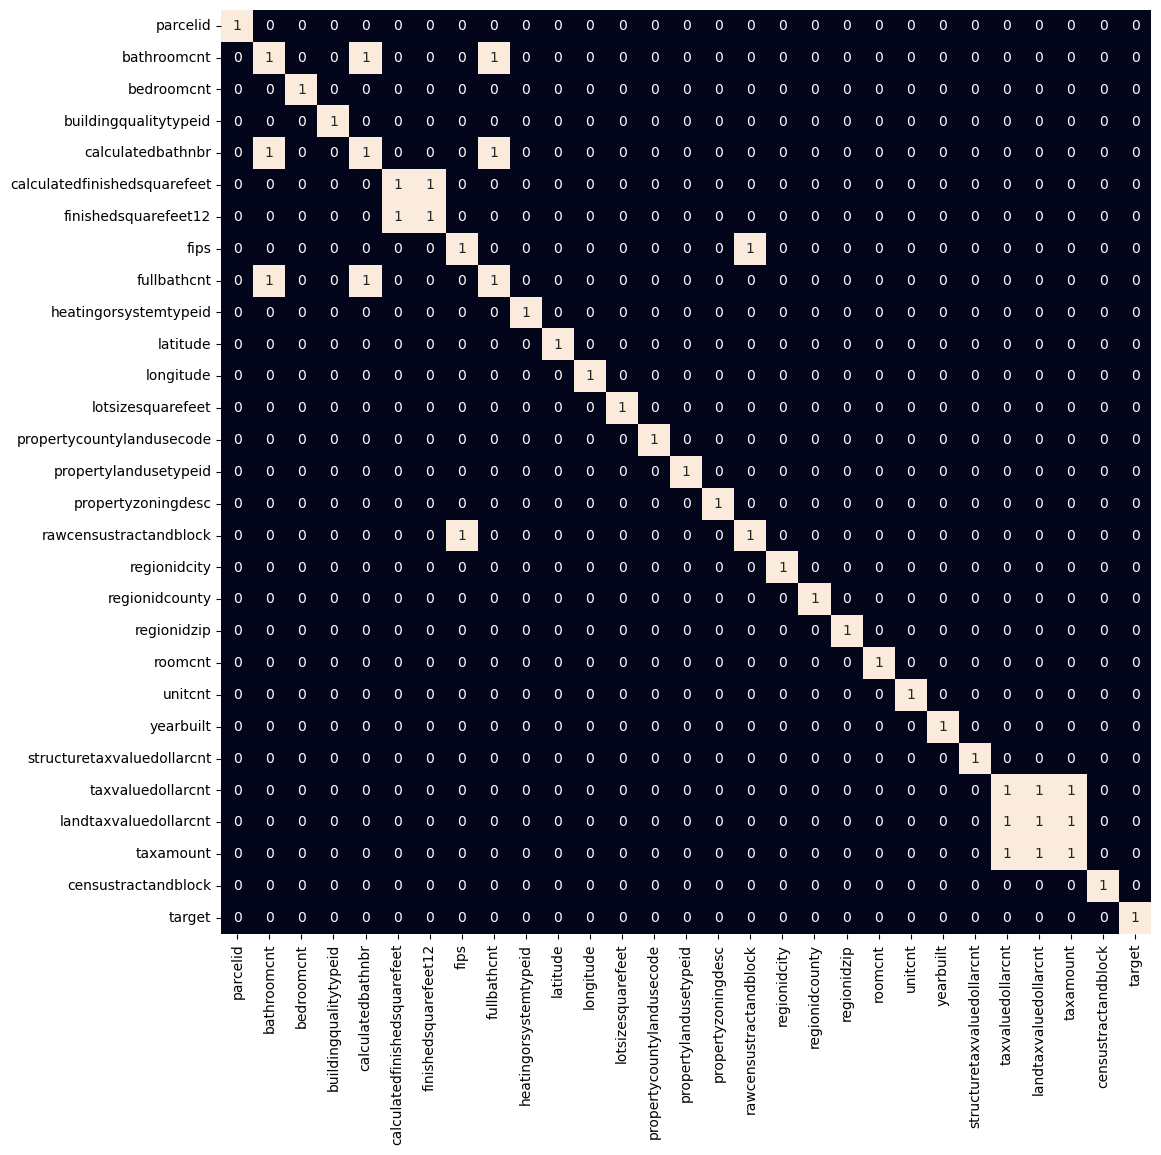

In [57]:
plt.figure(figsize=(12, 12))
sns.heatmap(df.corr()>0.8, annot=True, cbar=False)

In [58]:
to_remove = ['calculatedbathnbr', 'fullbathcnt', 'fips',
             'rawcensustractandblock', 'taxvaluedollarcnt',
             'finishedsquarefeet12', 'landtaxvaluedollarcnt']

In [59]:
df.drop(to_remove, axis=1, inplace=True)

<Axes: >

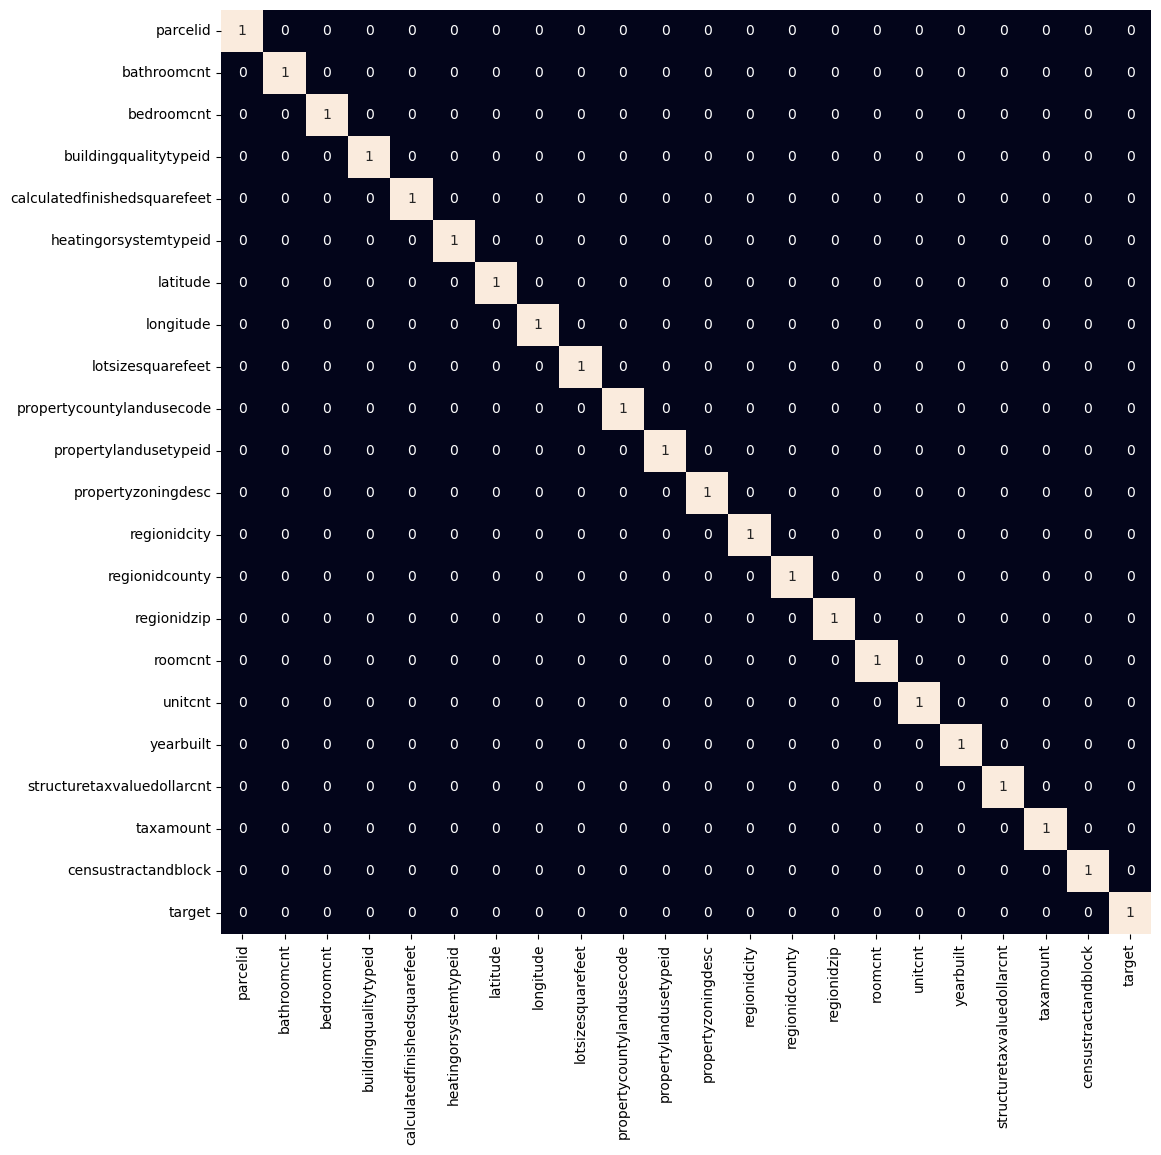

In [60]:
plt.figure(figsize=(12, 12))
sns.heatmap(df.corr()>0.8, annot=True, cbar=False)

### Step 6: Model Training

In [62]:
features = df.drop(['target'], axis=1)
target = df['target']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [64]:
scaler = StandardScaler()

In [65]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [66]:
models = [LinearRegression(), XGBRegressor(), Lasso(), RandomForestRegressor(), Ridge()]

In [69]:
for model in models:
    model.fit(X_train, y_train)
    print(f'{model}:')
    train_preds = model.predict(X_train)
    print('Training Error:', metrics.mean_absolute_error(y_train, train_preds))
    test_preds = model.predict(X_test)
    print('Testing Error:', metrics.mean_absolute_error(y_test, test_preds))
    print('----------------------------')

LinearRegression():
Training Error: 0.06205451159632781
Testing Error: 0.06298807292290502
----------------------------
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...):
Training Error: 0.056103280344744
Testing Error: 0.06536822752997454
----------------------------
Lasso():
Training Error: 0.0620